# Кластеризация и разделение сигналов на типы

Цель работы — разделить сигналы из `data_4W_sem.csv` на группы по форме импульса, присвоить тип каждой исходной строке и описать характерные особенности найденных классов.

Основной различающий признак — скорость спада импульса от 90% до 10% его амплитуды. Этот параметр позволяет отделить широкие сигналы с длинным хвостом от узких сигналов с быстрым спадом и при этом меньше зависит от абсолютной амплитуды, чем обычная ширина FWHM.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (13, 6), "font.size": 12})

DATA_PATH = Path("data_4W_sem.csv")
OUTPUT_DIR = Path("signal_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

BASELINE_BINS = 80
MIN_TRAIN_AMPLITUDE = 30
OUTLIER_THRESHOLD_MAD = 5.0
RANDOM_STATE = 42

## 1. Загрузка и подготовка данных

Строка CSV содержит один сигнал из 500 последовательных отсчётов. В наборе много точных повторов, поэтому модель обучается на уникальных формах. После кластеризации найденный тип переносится обратно на все 3000 исходных строк.

In [2]:
raw = pd.read_csv(DATA_PATH, header=None)
values = raw.to_numpy(dtype=float)

first_occurrence = ~raw.duplicated()
unique_raw = raw.loc[first_occurrence]
unique_values = unique_raw.to_numpy(dtype=float)
first_original_indices = unique_raw.index.to_numpy()

baselines = np.median(unique_values[:, :BASELINE_BINS], axis=1)
signals = unique_values - baselines[:, None]
amplitudes = signals.max(axis=1)
peak_bins = signals.argmax(axis=1)
normalized_signals = signals / amplitudes[:, None]

print(f"Исходных строк: {len(values)}")
print(f"Уникальных форм: {len(unique_values)}")
print(f"Точных повторов: {len(values) - len(unique_values)}")

Исходных строк: 3000
Уникальных форм: 583
Точных повторов: 2417


## 2. Признаки формы и отделение выбросов

Для каждой формы рассчитываются:

- амплитуда после вычитания базовой линии;
- положение максимума;
- FWHM — ширина на половине высоты;
- время спада от 90% до 10% амплитуды;
- скорость спада `0,8 × амплитуда / время спада`;
- нормированная площадь и отношение площади хвоста к площади фронта.

Выбросом считается форма, у которой хотя бы один из пяти базовых параметров отклоняется более чем на 5 MAD от медианы. Выбросы не участвуют в кластеризации и получают отдельную метку.

In [3]:
def first_below(signal, peak, amplitude, fraction):
    indices = np.flatnonzero(signal[peak:] <= fraction * amplitude)
    return peak + int(indices[0]) if indices.size else len(signal) - 1


def extract_features(signal):
    amplitude = float(signal.max())
    peak = int(signal.argmax())
    half_height = amplitude / 2

    left_candidates = np.flatnonzero(signal[:peak + 1] <= half_height)
    left = int(left_candidates[-1]) if left_candidates.size else 0
    right_candidates = np.flatnonzero(signal[peak:] <= half_height)
    right = peak + int(right_candidates[0]) if right_candidates.size else len(signal) - 1

    t90 = first_below(signal, peak, amplitude, 0.9)
    t10 = first_below(signal, peak, amplitude, 0.1)
    fall_time = max(t10 - t90, 1)
    decay_speed = 0.8 * amplitude / fall_time

    positive = np.clip(signal, 0, None)
    normalized_area = float(positive.sum() / max(amplitude, 1e-12))
    leading_area = float(positive[max(0, peak - 50):peak + 1].sum())
    trailing_area = float(positive[peak:min(len(signal), peak + 150)].sum())
    tail_ratio = trailing_area / max(leading_area, 1e-12)

    return amplitude, peak, right - left, normalized_area, tail_ratio, fall_time, decay_speed


feature_names = [
    "amplitude", "peak_bin", "fwhm", "normalized_area", "tail_ratio",
    "fall_time_90_10", "decay_speed"
]
feature_values = np.array([extract_features(signal) for signal in signals])
features = pd.DataFrame(feature_values, columns=feature_names)
features[["peak_bin", "fwhm", "fall_time_90_10"]] = features[
    ["peak_bin", "fwhm", "fall_time_90_10"]
].astype(int)
features.insert(0, "unique_shape_id", np.arange(len(features)))
features.insert(1, "first_original_index", first_original_indices)

base_matrix = features[["amplitude", "peak_bin", "fwhm", "normalized_area", "tail_ratio"]].to_numpy()
median = np.median(base_matrix, axis=0)
mad = 1.4826 * np.median(np.abs(base_matrix - median), axis=0)
mad[mad == 0] = 1.0
features["robust_distance"] = np.abs((base_matrix - median) / mad).max(axis=1)
features["is_outlier"] = features["robust_distance"] > OUTLIER_THRESHOLD_MAD

print(f"Уникальных выбросов: {int(features['is_outlier'].sum())}")
display(features.loc[features["is_outlier"]].round(3))

Уникальных выбросов: 2


,unique_shape_id,first_original_index,amplitude,peak_bin,fwhm,normalized_area,tail_ratio,fall_time_90_10,decay_speed,robust_distance,is_outlier
2,2,2,1.960,135,2,74.959,4.966,1,1.568,9.780,True
291,291,396,2.453,141,3,116.302,2.282,23,0.085,7.757,True


## 3. Выбор числа типов

Для надёжного определения центров используются нормальные сигналы с амплитудой не ниже 30. У более слабых импульсов шум заметно искажает точки пересечения уровней 90% и 10%, поэтому они классифицируются после обучения модели и получают низкую уверенность.

Проверяются варианты от двух до шести кластеров. Качество оценивается коэффициентом силуэта: чем он ближе к 1, тем компактнее группы и тем сильнее они отделены друг от друга.

,Число типов,Silhouette score
0,2,0.712
1,3,0.873
2,4,0.791
3,5,0.733
4,6,0.631


Оптимальное число типов: 3


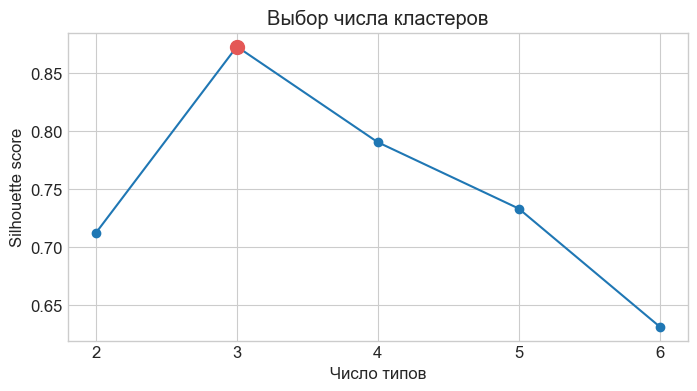

In [4]:
training_mask = (~features["is_outlier"]).to_numpy() & (amplitudes >= MIN_TRAIN_AMPLITUDE)
X_train = features.loc[training_mask, ["decay_speed"]].to_numpy()

silhouette_rows = []
models = {}
for n_clusters in range(2, 7):
    model = KMeans(n_clusters=n_clusters, n_init=50, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    models[n_clusters] = model
    silhouette_rows.append({"Число типов": n_clusters, "Silhouette score": score})

silhouette_table = pd.DataFrame(silhouette_rows)
best_k = int(silhouette_table.loc[silhouette_table["Silhouette score"].idxmax(), "Число типов"])

display(silhouette_table.round(3))
print(f"Оптимальное число типов: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(silhouette_table["Число типов"], silhouette_table["Silhouette score"], marker="o")
plt.scatter([best_k], [silhouette_table["Silhouette score"].max()], s=100, color="#e45756", zorder=3)
plt.xticks(silhouette_table["Число типов"])
plt.xlabel("Число типов")
plt.ylabel("Silhouette score")
plt.title("Выбор числа кластеров")
plt.show()

**Вывод о числе групп.** Максимальный silhouette score равен 0,873 при трёх кластерах. Значение заметно выше вариантов с двумя, четырьмя, пятью и шестью группами. Поэтому в дальнейшем используются три типа сигналов.

## 4. Обучение модели и присвоение типов

Номера кластеров KMeans случайны, поэтому типы переупорядочиваются по скорости спада:

- **Тип 1 — медленный широкий импульс**;
- **Тип 2 — промежуточный импульс**;
- **Тип 3 — быстрый узкий импульс**.

Две аномальные формы сохраняют отдельную метку `Выброс`.

In [5]:
model = models[best_k]
cluster_centers = model.cluster_centers_.ravel()
ordered_clusters = np.argsort(cluster_centers)
cluster_to_type = {cluster: type_id + 1 for type_id, cluster in enumerate(ordered_clusters)}

normal_mask = (~features["is_outlier"]).to_numpy()
predicted_clusters = model.predict(features.loc[normal_mask, ["decay_speed"]].to_numpy())
type_ids = np.zeros(len(features), dtype=int)
type_ids[normal_mask] = [cluster_to_type[label] for label in predicted_clusters]

type_names = {
    0: "Выброс",
    1: "Тип 1 — медленный широкий",
    2: "Тип 2 — промежуточный",
    3: "Тип 3 — быстрый узкий",
}
features["type_id"] = type_ids
features["signal_type"] = [type_names[value] for value in type_ids]
features["classification_confidence"] = np.where(
    features["is_outlier"], "не применяется",
    np.where(features["amplitude"] >= MIN_TRAIN_AMPLITUDE, "высокая", "низкая")
)

print("Центры типов по скорости спада:")
for cluster in ordered_clusters:
    type_id = cluster_to_type[cluster]
    print(f"  Тип {type_id}: {cluster_centers[cluster]:.3f} ед./отсчёт")

Центры типов по скорости спада:
  Тип 1: 0.724 ед./отсчёт
  Тип 2: 0.864 ед./отсчёт
  Тип 3: 1.023 ед./отсчёт


In [6]:
# Восстанавливаем связь уникальных форм со всеми исходными строками.
row_keys = [row.tobytes() for row in np.ascontiguousarray(values)]
unique_keys = [row.tobytes() for row in np.ascontiguousarray(unique_values)]
key_to_unique = {key: idx for idx, key in enumerate(unique_keys)}
unique_ids = np.array([key_to_unique[key] for key in row_keys])
features["repeat_count"] = np.bincount(unique_ids, minlength=len(unique_values))

all_types = pd.DataFrame({
    "original_index": np.arange(len(values)),
    "unique_shape_id": unique_ids,
    "type_id": features.loc[unique_ids, "type_id"].to_numpy(),
    "signal_type": features.loc[unique_ids, "signal_type"].to_numpy(),
    "classification_confidence": features.loc[unique_ids, "classification_confidence"].to_numpy(),
    "amplitude": features.loc[unique_ids, "amplitude"].to_numpy(),
    "peak_bin": features.loc[unique_ids, "peak_bin"].to_numpy(),
    "fwhm": features.loc[unique_ids, "fwhm"].to_numpy(),
    "fall_time_90_10": features.loc[unique_ids, "fall_time_90_10"].to_numpy(),
    "decay_speed": features.loc[unique_ids, "decay_speed"].to_numpy(),
    "is_outlier": features.loc[unique_ids, "is_outlier"].to_numpy(),
})

high_confidence = features["classification_confidence"] == "высокая"
summary_rows = []
for type_id in range(1, best_k + 1):
    member_mask = features["type_id"] == type_id
    reliable_mask = member_mask & high_confidence
    summary_rows.append({
        "Тип": type_names[type_id],
        "Уникальных форм": int(member_mask.sum()),
        "Исходных строк": int(features.loc[member_mask, "repeat_count"].sum()),
        "Надёжных форм": int(reliable_mask.sum()),
        "Средняя амплитуда надёжных": features.loc[reliable_mask, "amplitude"].mean(),
        "Средняя FWHM надёжных": features.loc[reliable_mask, "fwhm"].mean(),
        "Среднее время спада": features.loc[reliable_mask, "fall_time_90_10"].mean(),
        "Средняя скорость спада": features.loc[reliable_mask, "decay_speed"].mean(),
    })

type_summary = pd.DataFrame(summary_rows)
display(type_summary.round(3))

print("Распределение всех 3000 строк:")
display(all_types["signal_type"].value_counts().rename_axis("Тип").to_frame("Количество"))

,Тип,Уникальных форм,Исходных строк,Надёжных форм,Средняя амплитуда надёжных,Средняя FWHM надёжных,Среднее время спада,Средняя скорость спада
0,Тип 1 — медленный широкий,266,1378,166,108.058,102.910,119.681,0.724
1,Тип 2 — промежуточный,161,798,161,109.366,91.932,101.199,0.864
2,Тип 3 — быстрый узкий,154,811,154,118.106,87.409,92.208,1.023


Распределение всех 3000 строк:


,Количество
Тип,
Тип 1 — медленный широкий,1378
Тип 3 — быстрый узкий,811
Тип 2 — промежуточный,798
Выброс,13


## 5. Визуализация найденных типов

На первом графике показано положение сигналов в координатах «амплитуда — время спада». На втором сравниваются нормированные формы. Тонкие линии — отдельные надёжные уникальные сигналы, толстая линия — средняя форма типа.

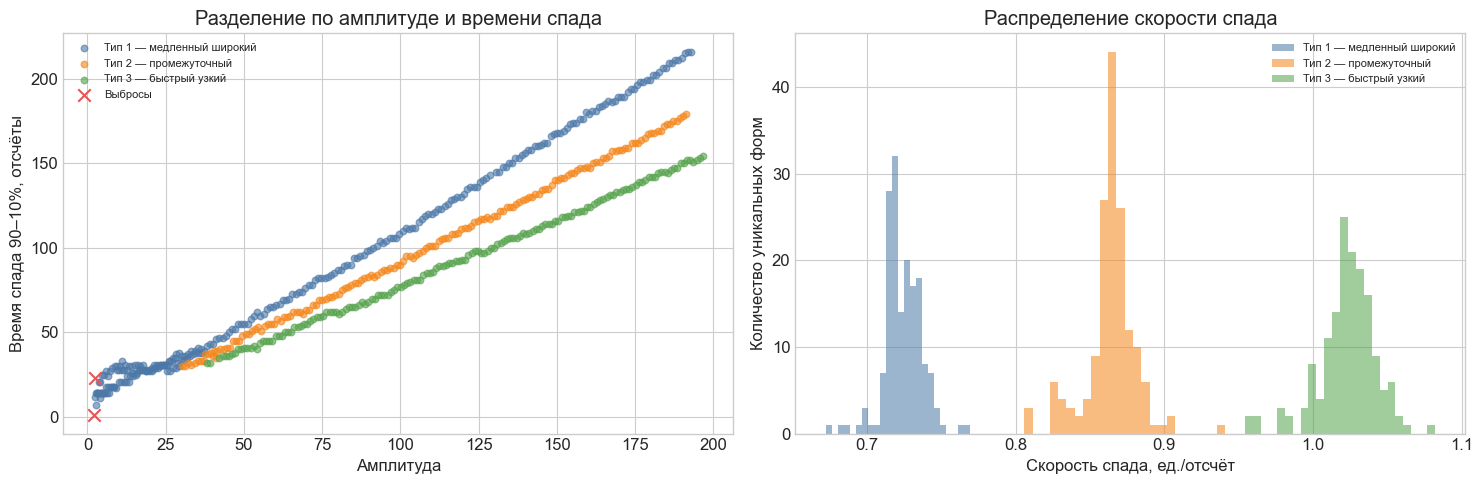

In [7]:
colors = {1: "#4c78a8", 2: "#f58518", 3: "#54a24b"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for type_id in range(1, best_k + 1):
    mask = features["type_id"] == type_id
    axes[0].scatter(
        features.loc[mask, "amplitude"],
        features.loc[mask, "fall_time_90_10"],
        s=22,
        alpha=0.6,
        color=colors[type_id],
        label=type_names[type_id],
    )
axes[0].scatter(
    features.loc[features["is_outlier"], "amplitude"],
    features.loc[features["is_outlier"], "fall_time_90_10"],
    color="#e45756", s=80, marker="x", label="Выбросы"
)
axes[0].set_title("Разделение по амплитуде и времени спада")
axes[0].set_xlabel("Амплитуда")
axes[0].set_ylabel("Время спада 90–10%, отсчёты")
axes[0].legend(fontsize=8)

for type_id in range(1, best_k + 1):
    mask = (features["type_id"] == type_id) & high_confidence
    axes[1].hist(
        features.loc[mask, "decay_speed"], bins=24, alpha=0.55,
        color=colors[type_id], label=type_names[type_id]
    )
axes[1].set_title("Распределение скорости спада")
axes[1].set_xlabel("Скорость спада, ед./отсчёт")
axes[1].set_ylabel("Количество уникальных форм")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

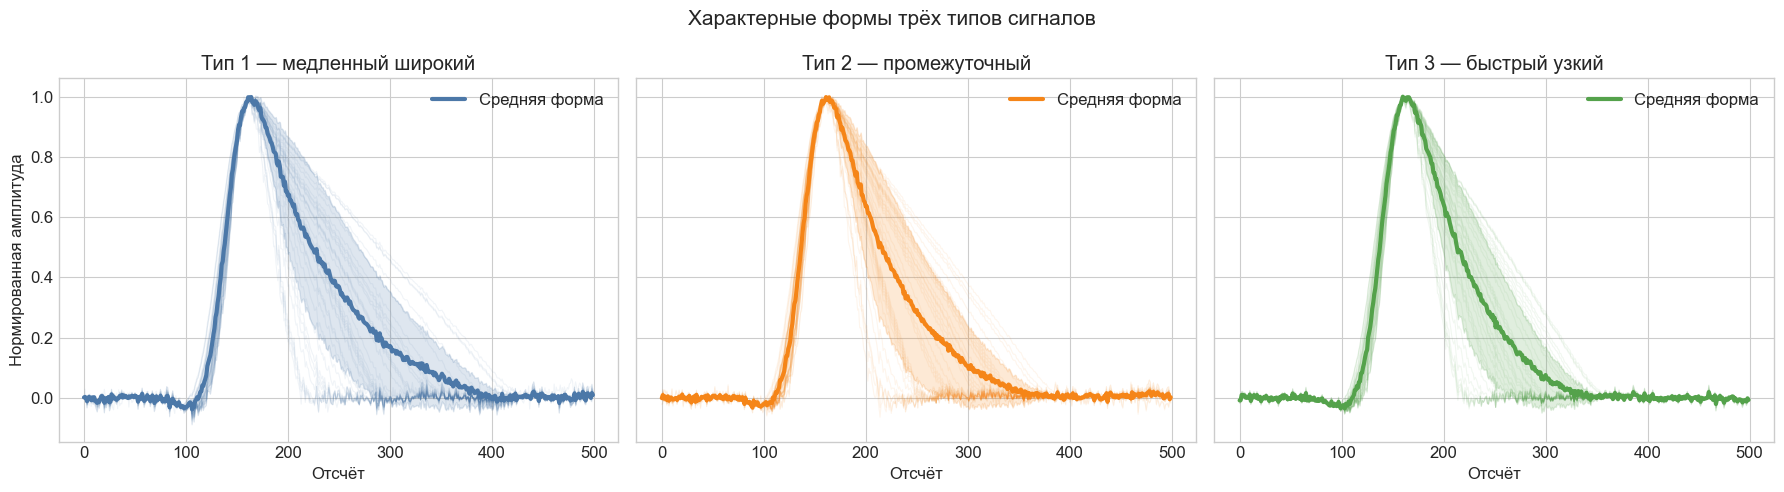

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
rng = np.random.default_rng(RANDOM_STATE)

for ax, type_id in zip(axes, range(1, best_k + 1)):
    indices = np.flatnonzero((features["type_id"] == type_id) & high_confidence)
    shown = rng.choice(indices, size=min(35, len(indices)), replace=False)
    for idx in shown:
        ax.plot(normalized_signals[idx], color=colors[type_id], alpha=0.08, lw=0.8)
    mean_shape = normalized_signals[indices].mean(axis=0)
    std_shape = normalized_signals[indices].std(axis=0)
    x = np.arange(len(mean_shape))
    ax.plot(x, mean_shape, color=colors[type_id], lw=3, label="Средняя форма")
    ax.fill_between(x, mean_shape - std_shape, mean_shape + std_shape, color=colors[type_id], alpha=0.18)
    ax.set_title(type_names[type_id])
    ax.set_xlabel("Отсчёт")
    ax.legend()

axes[0].set_ylabel("Нормированная амплитуда")
fig.suptitle("Характерные формы трёх типов сигналов", fontsize=15)
plt.tight_layout()
plt.show()

## 6. Сохранение классификации

Таблица `all_signal_types.csv` содержит тип каждой исходной строки. Поле `classification_confidence` показывает надёжность: сигналы с амплитудой не ниже 30 использовались для определения кластеров и имеют высокую уверенность; слабые сигналы классифицированы по ближайшему центру, но имеют низкую уверенность.

In [9]:
all_types.to_csv(OUTPUT_DIR / "all_signal_types.csv", index=False)
type_summary.to_csv(OUTPUT_DIR / "type_summary.csv", index=False)

print("Сохранено:")
print(" - signal_analysis/all_signal_types.csv")
print(" - signal_analysis/type_summary.csv")
display(all_types.head(10).round(3))

Сохранено:
 - signal_analysis/all_signal_types.csv
 - signal_analysis/type_summary.csv


,original_index,unique_shape_id,type_id,signal_type,classification_confidence,amplitude,peak_bin,fwhm,fall_time_90_10,decay_speed,is_outlier
0,0,0,1,Тип 1 — медленный широкий,высокая,163.421,164,145,183,0.714,False
1,1,1,2,Тип 2 — промежуточный,высокая,107.085,164,91,98,0.874,False
2,2,2,0,Выброс,не применяется,1.960,135,2,1,1.568,True
3,3,3,2,Тип 2 — промежуточный,высокая,182.164,161,138,169,0.862,False
4,4,4,3,Тип 3 — быстрый узкий,высокая,125.840,166,92,97,1.038,False
5,5,5,1,Тип 1 — медленный широкий,низкая,29.894,157,43,34,0.703,False
6,6,6,1,Тип 1 — медленный широкий,высокая,46.132,161,57,52,0.710,False
7,7,7,2,Тип 2 — промежуточный,высокая,58.626,161,60,55,0.853,False
8,8,8,2,Тип 2 — промежуточный,высокая,96.763,164,84,88,0.880,False
9,9,9,2,Тип 2 — промежуточный,высокая,157.522,164,123,147,0.857,False


## Итоговые выводы

1. **Данные разделяются на три типа формы.** Оптимум по silhouette score достигается при трёх кластерах: 0,873. Это указывает на хорошо разделённые группы по скорости спада.
2. **Тип 1 — медленный широкий импульс.** Центр скорости спада равен примерно 0,724 ед./отсчёт. Среди надёжных сигналов средняя FWHM составляет около 103 отсчётов, среднее время спада — около 120 отсчётов. К типу отнесено 1378 исходных строк.
3. **Тип 2 — промежуточный импульс.** Центр скорости спада равен примерно 0,864 ед./отсчёт. Средняя FWHM составляет около 92 отсчётов, среднее время спада — около 101 отсчёта. К типу отнесено 798 строк.
4. **Тип 3 — быстрый узкий импульс.** Центр скорости спада равен примерно 1,023 ед./отсчёт. Средняя FWHM составляет около 87 отсчётов, среднее время спада — около 92 отсчётов. К типу отнесено 811 строк.
5. **Выбросы отделены от физических типов.** Две уникальные шумоподобные формы встречаются в 13 строках и сохраняют отдельную метку `Выброс`.
6. **Для слабых импульсов классификация менее надёжна.** 523 строки с амплитудой ниже 30 попали в тип 1 по ближайшему центру, но отмечены низкой уверенностью. Их не следует использовать для окончательной физической интерпретации без дополнительной проверки.
7. **Физические названия классов по имеющимся данным установить нельзя.** Кластеры достоверно различаются по форме, но для подписей вроде «нейтрон», «гамма-квант» или «шум» нужны эталонные метки или калибровочные измерения. Поэтому используются нейтральные названия по скорости и ширине импульса.